In [ ]:
!nvidia-smi

Wed Apr  1 07:11:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             40W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

Torch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
import zipfile

zip_path = "einstein_rings_128.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    image_files = [f for f in z.namelist() if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

print("Total images:", len(image_files))

Total images: 195


In [ ]:
import os
from pathlib import Path

ZIP_PATH = "/content/einstein_rings_128.zip"
WORK_DIR = "/content/euclid_project"
DATA_DIR = os.path.join(WORK_DIR, "data")
OUTPUT_DIR = "/content/diffusion_outputs"

os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("ZIP_PATH:", ZIP_PATH)
print("WORK_DIR:", WORK_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

ZIP_PATH: /content/einstein_rings_128.zip
WORK_DIR: /content/euclid_project
DATA_DIR: /content/euclid_project/data
OUTPUT_DIR: /content/diffusion_outputs


In [ ]:
import zipfile
import os

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"Zip file not found: {ZIP_PATH}")

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(WORK_DIR)

print("Unzip complete")

for root, dirs, files in os.walk(WORK_DIR):
    print(root, "->", len(files), "files")

Unzip complete
/content/euclid_project -> 195 files


In [ ]:
%%capture
!pip install -U diffusers[training]

In [ ]:
%%capture
!sudo apt -qq install git-lfs
!git config --global credential.helper store

In [ ]:
from dataclasses import dataclass

@dataclass
class TrainingConfig:
    image_size = 32 # the generated image resolution
    train_batch_size = 8
    eval_batch_size = 8  # how many images to sample during evaluation
    num_epochs = 50
    gradient_accumulation_steps = 1
    learning_rate = 1e-4
    lr_warmup_steps = 500
    save_image_epochs = 10
    save_model_epochs = 30
    mixed_precision = 'fp16'  # `no` for float32, `fp16` for automatic mixed precision
    output_dir = 'ddpm-butterflies-128'  # the model namy locally and on the HF Hub

    push_to_hub = True  # whether to upload the saved model to the HF Hub
    hub_private_repo = False
    overwrite_output_dir = True  # overwrite the old model when re-running the notebook
    seed = 0

config = TrainingConfig()

In [ ]:
from pathlib import Path
import os

data = "/content/euclid_project"

valid_exts = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}

best_folder = None
best_count = 0

for root, dirs, files in os.walk(data):
    count = sum(1 for f in files if Path(f).suffix.lower() in valid_exts)
    if count > best_count:
        best_count = count
        best_folder = root

print("Best image folder:", best_folder)
print("Number of images:", best_count)

Best image folder: /content/euclid_project
Number of images: 195


Found images: 195


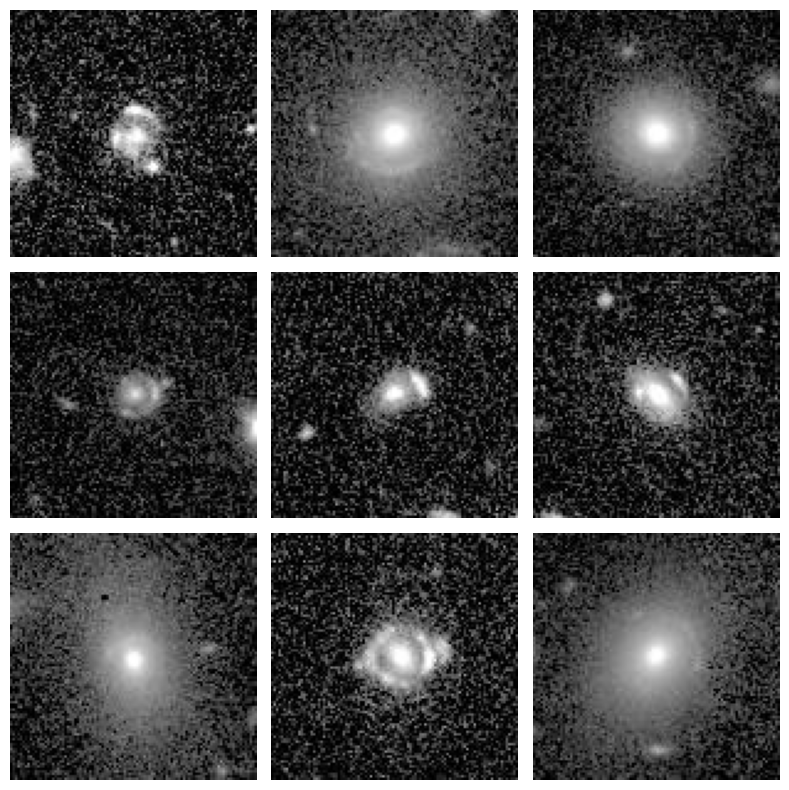

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import random

image_paths = []
for p in Path(data).glob("*"):
    if p.suffix.lower() in valid_exts:
        image_paths.append(str(p))

print("Found images:", len(image_paths))

sample_paths = random.sample(image_paths, min(9, len(image_paths)))

plt.figure(figsize=(8, 8))
for i, path in enumerate(sample_paths, 1):
    img = Image.open(path).convert("RGB")
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from torchvision import transforms

# preprocess = transforms.Compose(
#     [
#         transforms.Resize((config.image_size, config.image_size)),
#         transforms.RandomHorizontalFlip(),
#         transforms.ToTensor(),
#         transforms.Normalize([0.5], [0.5]),
#     ]
# )
def log_transform(x):
    # This brings out the faint arcs without blowing out the center
    return torch.log1p(x * 100) / torch.log1p(torch.tensor(100.0))

preprocess = transforms.Compose([
    transforms.Resize((config.image_size, config.image_size)),
    transforms.RandomRotation(180),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

In [ ]:
import torch
train_dataloader = torch.utils.data.DataLoader(data, batch_size=config.train_batch_size, shuffle=True)

In [ ]:
from diffusers import UNet2DModel


model = UNet2DModel(
    sample_size=config.image_size,  # the target image resolution
    in_channels=3,  # the number of input channels, 3 for RGB images
    out_channels=3,  # the number of output channels
    layers_per_block=2,  # how many ResNet layers to use per UNet block
    block_out_channels=(32, 32, 64, 64, 128, 128),  # the number of output channes for each UNet block
    down_block_types=(
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",  # a regular ResNet upsampling block
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D"
      ),
)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
from PIL import Image
from pathlib import Path
from collections import Counter

sizes = []

for p in Path(data).glob("*"):
    if p.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp", ".webp"]:
        img = Image.open(p)
        sizes.append(img.size)

# Count occurrences of each size
size_count = Counter(sizes)

print("Image size distribution:")
for size, count in size_count.items():
    print(f"{size}: {count} images")

if sample_paths:
  example_image_path = sample_paths[0]
  example_image = Image.open(example_image_path).convert("RGB")
  preprocessed_image = preprocess(example_image)
  print('Input shape after preprocessing:', preprocessed_image.shape)

else:
  print("No sample paths found to determine image shape.")

Image size distribution:
(100, 100): 195 images
Input shape after preprocessing: torch.Size([3, 32, 32])


In [ ]:
import torch
from PIL import Image
from torchvision import transforms
from pathlib import Path

transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),            # [0,1]
    transforms.Normalize([0.5]*3, [0.5]*3)  # [-1,1]
])

images = []

for p in Path(data).glob("*"):
    if p.suffix.lower() in valid_exts:
        img = Image.open(p).convert("RGB")
        img = transform(img)
        images.append(img)

images = torch.stack(images)  # shape: [N, 3, 64, 64]

print("Tensor shape:", images.shape)

Tensor shape: torch.Size([195, 3, 32, 32])


In [ ]:
# from diffusers import DDPMScheduler

# noise_scheduler = DDPMScheduler(num_train_timesteps=200)

In [ ]:
from diffusers import DDPMScheduler

noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2")

noise = torch.randn_like(images)

timesteps = torch.randint(0, 100, (images.shape[0],))

noisy_images = noise_scheduler.add_noise(images, noise, timesteps)

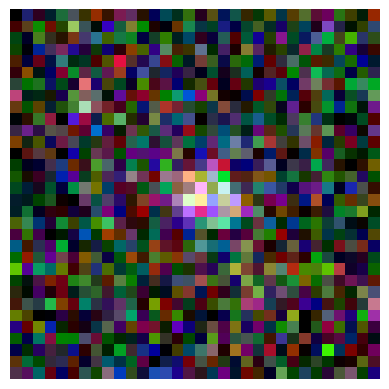

In [ ]:
import matplotlib.pyplot as plt

img = noisy_images[190]

# convert back to [0,1]
img = (img.clamp(-1, 1) + 1) / 2
img = img.permute(1, 2, 0).cpu().numpy()



plt.imshow(img)
plt.axis("off")
plt.show()

Your original astronomy images are probably close to grayscale, but you converted them to RGB. Then Gaussian noise is added independently to each channel, so the result becomes colorful static. That is normal.


Show the same image at multiple timesteps:

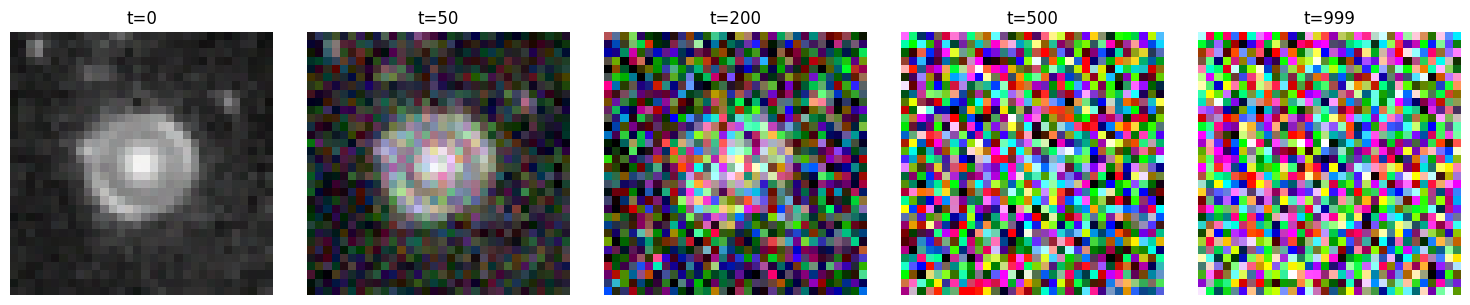

In [ ]:
import matplotlib.pyplot as plt
import torch

img = images[3:4]  # one image, keep batch dim

steps = [0, 50, 200, 500, 999]

plt.figure(figsize=(15, 3))
for i, step in enumerate(steps, 1):
    noise = torch.randn_like(img)
    t = torch.tensor([step])
    noisy = noise_scheduler.add_noise(img, noise, t)

    show = (noisy[0].clamp(-1, 1) + 1) / 2
    show = show.permute(1, 2, 0).cpu().numpy()

    plt.subplot(1, len(steps), i)
    plt.imshow(show)
    plt.title(f"t={step}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# 1. Ensure 'images' is a single big tensor (you already did this with torch.stack)
# images.shape should be [195, 3, 64, 64]

# 2. Wrap it in a Dataset so the DataLoader knows what to do with it
dataset = TensorDataset(images)

# 3. Create the DataLoader
train_dataloader = DataLoader(
    dataset,
    batch_size=config.train_batch_size,
    shuffle=True
)

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import torch.nn.functional as F
# 1. Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Ensure your model is on that device (do this once during setup)
model.to(device)

# 3. Move your tensors to the device inside your training loop
noisy_images = noisy_images.to(device)
timesteps = timesteps.to(device)
noise = noise.to(device) # Don't forget the target noise for the loss function!

# Now this will work
noise_pred = model(noisy_images, timesteps).sample
loss = F.mse_loss(noise_pred, noise)


In [ ]:
# import torch.nn.functional as F

# noise_pred = model(noisy_images, timesteps).sample
# loss = F.mse_loss(noise_pred, noise)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

In [ ]:
from diffusers.optimization import get_cosine_schedule_with_warmup

lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=config.lr_warmup_steps,
    num_training_steps=(len(train_dataloader) * config.num_epochs),
)

In [ ]:
from diffusers import DDPMPipeline

import math

def make_grid(images, rows, cols):
    w, h = images[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    for i, image in enumerate(images):
        grid.paste(image, box=(i%cols*w, i//cols*h))
    return grid

def evaluate(config, epoch, pipeline):
    # Sample some images from random noise (this is the backward diffusion process).
    # The default pipeline output type is `List[PIL.Image]`
    images = pipeline(
        batch_size = config.eval_batch_size,
        generator=torch.manual_seed(config.seed),
    ).images

    # Make a grid out of the images
    image_grid = make_grid(images, rows=4, cols=4)

    # Save the images
    test_dir = os.path.join(config.output_dir, "samples")
    os.makedirs(test_dir, exist_ok=True)
    image_grid.save(f"{test_dir}/{epoch:04d}.png")

In [ ]:
from accelerate import Accelerator
from accelerate.utils import ProjectConfiguration
from huggingface_hub import create_repo, upload_folder

from tqdm.auto import tqdm
from pathlib import Path
import os

def train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler):
    # Initialize accelerator and tensorboard logging
    logging_dir = os.path.join(config.output_dir, "logs")
    accelerator_project_config = ProjectConfiguration(project_dir=config.output_dir, logging_dir=logging_dir)
    accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
        log_with="tensorboard",
        project_config=accelerator_project_config,
    )
    if accelerator.is_main_process:
        if config.push_to_hub:
            repo_id = create_repo(
                repo_id=Path(config.output_dir).name, exist_ok=True
            ).repo_id
        elif config.output_dir is not None:
            os.makedirs(config.output_dir, exist_ok=True)
        accelerator.init_trackers("train_example")

    # Prepare everything
    # There is no specific order to remember, you just need to unpack the
    # objects in the same order you gave them to the prepare method.
    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    global_step = 0

    # Now you train the model
    for epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        for step, batch in enumerate(train_dataloader):
            # clean_images = batch
            # # Sample noise to add to the images
            # noise = torch.randn(clean_images.shape).to(clean_images.device)
            # bs = clean_images.shape[0]

            clean_images = batch[0]

            # Move to GPU
            clean_images = clean_images.to(accelerator.device)

            # Sample noise
            noise = torch.randn_like(clean_images)
            bs = clean_images.shape[0]

            # Sample a random timestep for each image
            timesteps = torch.randint(0, noise_scheduler.num_train_timesteps, (bs,), device=clean_images.device).long()

            # Add noise to the clean images according to the noise magnitude at each timestep
            # (this is the forward diffusion process)
            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            with accelerator.accumulate(model):
                # Predict the noise residual
                noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
                loss = F.mse_loss(noise_pred, noise)
                accelerator.backward(loss)

                accelerator.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            progress_bar.update(1)
            logs = {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0], "step": global_step}
            progress_bar.set_postfix(**logs)
            accelerator.log(logs, step=global_step)
            global_step += 1

        # After each epoch you optionally sample some demo images with evaluate() and save the model
        if accelerator.is_main_process:
            pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)

            if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
                evaluate(config, epoch, pipeline)

            if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
                if config.push_to_hub:
                    upload_folder(
                        repo_id=repo_id,
                        folder_path=config.output_dir,
                        commit_message=f"Epoch {epoch}",
                        ignore_patterns=["step_*", "epoch_*"],
                    )
                else:
                    pipeline.save_pretrained(config.output_dir)

In [ ]:
from accelerate import notebook_launcher
args = (config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler)

notebook_launcher(train_loop, args, num_processes=0.5)

Launching training on one GPU.


  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

...

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

ValueError: `num_inference_steps`: 1000 cannot be larger than `self.config.train_timesteps`: 100 as the unet model trained with this scheduler can only handle maximal 100 timesteps.

In [ ]:
import matplotlib.pyplot as plt

# Grab a sample from the model output
sample = noise_pred[0].detach().cpu()
# Reverse normalization correctly (ONLY ONCE)
sample = (sample / 2 + 0.5).clamp(0, 1)

# If it's 3-channel, convert to grayscale to see the ring structure better
if sample.shape[0] == 3:
    sample = sample.mean(dim=0)

plt.figure(figsize=(6,6))
# 'magma' or 'inferno' are much better for seeing faint astronomical rings
plt.imshow(sample, cmap='magma')
plt.title("Model Prediction (Heatmap)")
plt.axis("off")
plt.show()

In [ ]:
import glob

sample_images = sorted(glob.glob(f"{config.output_dir}/samples/*.png"))
Image.open(sample_images[-1])